In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# File path
file_path = Path("/content/3.csv")

In [ ]:
# Load dataset (fallback to latin1 if default encoding fails)
try:
    df = pd.read_csv(file_path)
except Exception:
    df = pd.read_csv(file_path, encoding="latin1")

In [ ]:
print("Shape:", df.shape)
print("Columns:", list(df.columns))

Shape: (48895, 16)
Columns: ['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


In [ ]:
# Quick peek
print("\n--- First 6 rows ---")
print(df.head(6))


--- First 6 rows ---
     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   
5  5099         Large Cozy 1 BR Apartment In Midtown East     7322   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   
5        Chris           Manhattan   Murray Hill 

In [ ]:
# 4) Column types & missing values
print("\n--- dtypes ---")
print(df.dtypes)


--- dtypes ---
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object


In [ ]:
missing_pct = (df.isna().sum() / len(df) * 100).round(2).sort_values(ascending=False)
print("\n--- Missing values (%) ---")
print(missing_pct.head(20))


--- Missing values (%) ---
last_review                       20.56
reviews_per_month                 20.56
host_name                          0.04
name                               0.03
neighbourhood_group                0.00
neighbourhood                      0.00
id                                 0.00
host_id                            0.00
longitude                          0.00
latitude                           0.00
room_type                          0.00
price                              0.00
number_of_reviews                  0.00
minimum_nights                     0.00
calculated_host_listings_count     0.00
availability_365                   0.00
dtype: float64


In [ ]:
# Numeric summary
num_df = df.select_dtypes(include=[np.number])
print("\n--- Numeric summary ---")
print(num_df.describe().T)


--- Numeric summary ---
                                  count          mean           std  \
id                              48895.0  1.901714e+07  1.098311e+07   
host_id                         48895.0  6.762001e+07  7.861097e+07   
latitude                        48895.0  4.072895e+01  5.453008e-02   
longitude                       48895.0 -7.395217e+01  4.615674e-02   
price                           48895.0  1.527207e+02  2.401542e+02   
minimum_nights                  48895.0  7.029962e+00  2.051055e+01   
number_of_reviews               48895.0  2.327447e+01  4.455058e+01   
reviews_per_month               38843.0  1.373221e+00  1.680442e+00   
calculated_host_listings_count  48895.0  7.143982e+00  3.295252e+01   
availability_365                48895.0  1.127813e+02  1.316223e+02   

                                       min           25%           50%  \
id                              2539.00000  9.471945e+06  1.967728e+07   
host_id                         2438.00000  7

In [ ]:
# Detect likely date column and parse it
date_candidates = [c for c in df.columns if any(k in c.lower() for k in ("date","order","time","timestamp"))]
parsed_date_col = None

# Explicitly check for 'last_review' as a date column
if 'last_review' in df.columns:
    parsed = pd.to_datetime(df['last_review'], errors="coerce", format="%d/%m/%Y")
    if parsed.notna().mean() > 0.5:
        parsed_date_col = 'last_review'
        df[parsed_date_col + "_parsed"] = parsed
    else: # If 'last_review' is not a date column, check other candidates
        for c in date_candidates:
            parsed = pd.to_datetime(df[c], errors="coerce")
            if parsed.notna().mean() > 0.5:
                parsed_date_col = c
                df[c + "_parsed"] = parsed
                break
else:
    for c in date_candidates:
        parsed = pd.to_datetime(df[c], errors="coerce")
        if parsed.notna().mean() > 0.5:
            parsed_date_col = c
            df[c + "_parsed"] = parsed
            break

In [ ]:
print("\nDate candidates:", date_candidates)
print("Parsed date column (if any):", parsed_date_col)


Date candidates: []
Parsed date column (if any): None


In [ ]:
# 7) Detect likely sales/revenue column (numeric)
sales_candidates = [c for c in df.columns if any(k in c.lower() for k in ("sales","revenue","amount","price","total"))]
sales_col = None
for c in sales_candidates:
    if pd.api.types.is_numeric_dtype(df[c]):
        sales_col = c
        break

In [ ]:
print("Sales candidates:", sales_candidates)
print("Detected sales column (numeric):", sales_col)

Sales candidates: ['price']
Detected sales column (numeric): price


In [ ]:
# 8) Monthly sales (if date + sales found)
if parsed_date_col and sales_col:
    df["month"] = df[parsed_date_col + "_parsed"].dt.to_period("M")
    monthly_sales = df.groupby("month", as_index=False)[sales_col].sum()
    monthly_sales["month_str"] = monthly_sales["month"].astype(str)
    print("\n--- Monthly sales (first 12 rows) ---")
    print(monthly_sales.head(12))

In [ ]:
# Plot monthly sales (matplotlib single plot)
if parsed_date_col and sales_col:
    plt.figure(figsize=(10,4))
    plt.plot(monthly_sales["month_str"], monthly_sales[sales_col], marker="o")
    plt.title("Monthly " + sales_col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("\nSkipping monthly sales: parsed date or numeric sales column not available.")


Skipping monthly sales: parsed date or numeric sales column not available.


In [ ]:
# Top products by sales (if product column exists)
product_candidates = [c for c in df.columns if any(k in c.lower() for k in ("product","item","sku","name","description"))]
product_col = None
for c in product_candidates:
    if df[c].nunique() > 1:
        product_col = c
        break

In [ ]:
print("Product candidates:", product_candidates)
print("Detected product-like column:", product_col)

Product candidates: ['name', 'host_name']
Detected product-like column: name


In [ ]:
if product_col and sales_col:
    top_products = (df.groupby(product_col, as_index=False)[sales_col]
                      .sum()
                      .sort_values(by=sales_col, ascending=False)
                      .head(10))
    print("\n--- Top 10 products by", sales_col, "---")
    print(top_products)



--- Top 10 products by price ---
                                                    name  price
1098                                 1-BR Lincoln Center  10000
19858                Furnished room in Astoria apartment  10000
26748    Luxury 1 bedroom apt. -stunning Manhattan views  10000
35493                Quiet, Clean, Lit @ LES & Chinatown   9999
2204   2br - The Heart of NYC: Manhattans Lower East ...   9999
40307                                 Spanish Harlem Apt   9999
7008   Beautiful/Spacious 1 bed luxury flat-TriBeCa/Soho   8500
19375                                      Film Location   8000
18032          East 72nd Townhouse by (Hidden by Airbnb)   7703
20100                               Gem of east Flatbush   7500


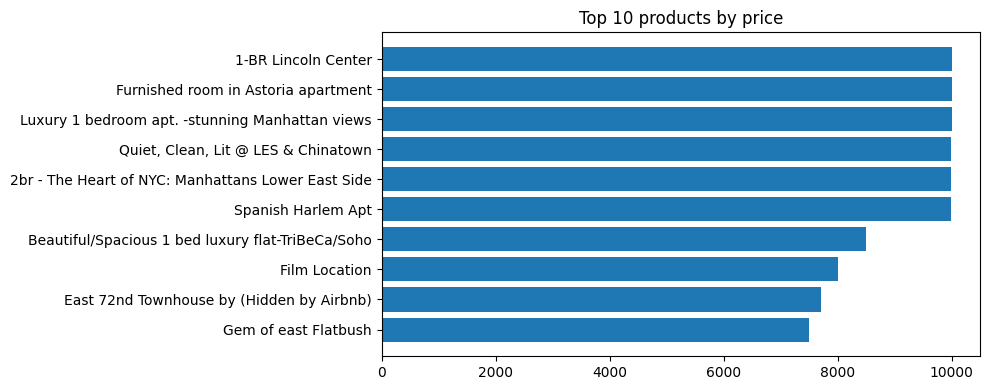

In [ ]:
if product_col and sales_col:
    plt.figure(figsize=(10,4))
    plt.barh(top_products[product_col].astype(str)[::-1], top_products[sales_col][::-1])
    plt.title("Top 10 products by " + sales_col)
    plt.tight_layout()
    plt.show()
else:
    print("\nSkipping top-products: product column or sales column missing.")


--- Correlation (numeric cols) ---
                                   id  host_id  latitude  longitude  price  \
id                              1.000    0.588    -0.003      0.091  0.011   
host_id                         0.588    1.000     0.020      0.127  0.015   
latitude                       -0.003    0.020     1.000      0.085  0.034   
longitude                       0.091    0.127     0.085      1.000 -0.150   
price                           0.011    0.015     0.034     -0.150  1.000   
minimum_nights                 -0.013   -0.017     0.025     -0.063  0.043   
number_of_reviews              -0.320   -0.140    -0.015      0.059 -0.048   
reviews_per_month               0.292    0.296    -0.010      0.146 -0.031   
calculated_host_listings_count  0.133    0.155     0.020     -0.115  0.057   
availability_365                0.085    0.203    -0.011      0.083  0.082   

                                minimum_nights  number_of_reviews  \
id                                  

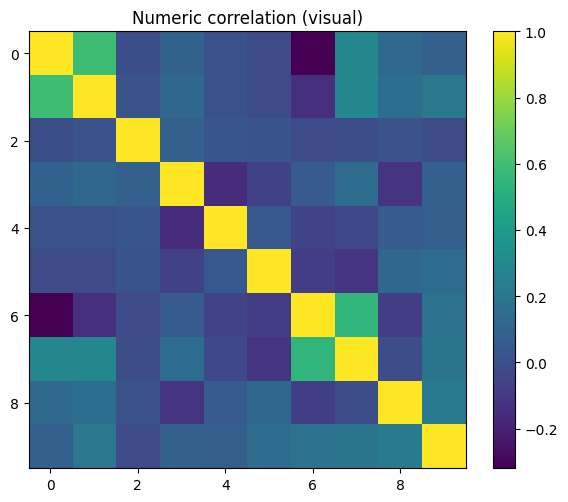

In [ ]:
# 10) Numeric correlation (if at least 2 numeric columns)
if num_df.shape[1] >= 2:
    corr = num_df.corr()
    print("\n--- Correlation (numeric cols) ---")
    print(corr.round(3))
    plt.figure(figsize=(6,5))
    plt.imshow(corr)
    plt.title("Numeric correlation (visual)")
    plt.colorbar()
    plt.tight_layout()
    plt.show()
else:
    print("\nNot enough numeric columns for correlation matrix.")

In [ ]:
# Basic cleaning & save a sample
clean_sample = df.drop_duplicates()
out_path = Path("/mnt/data/3_clean_sample.csv")
out_path.parent.mkdir(parents=True, exist_ok=True) # Create the directory if it doesn't exist
clean_sample.to_csv(out_path, index=False)
print("\nCleaned sample saved to:", out_path)


Cleaned sample saved to: /mnt/data/3_clean_sample.csv


In [ ]:
# Short checklist printed
print("""
Checklist / next steps:
- If date parsing failed: inspect the date column format(s) and re-run pd.to_datetime with a format argument.
- If sales values include currency signs or commas: remove them and convert to float, e.g.
    df['sales_clean'] = df['sales'].astype(str).str.replace('[^0-9.]','', regex=True).astype(float)
- Add group-by by category/region and pivot tables for deeper insights.
- Consider time-series decomposition if you have long time history.
""")


Checklist / next steps:
- If date parsing failed: inspect the date column format(s) and re-run pd.to_datetime with a format argument.
- If sales values include currency signs or commas: remove them and convert to float, e.g.
    df['sales_clean'] = df['sales'].astype(str).str.replace('[^0-9.]','', regex=True).astype(float)
- Add group-by by category/region and pivot tables for deeper insights.
- Consider time-series decomposition if you have long time history.

